In [13]:
import numpy as np, random, os, math

random.seed(1234)

l = os.listdir('breast-histopathology-images/versions/1')
n = random.sample(l, len(l))

train_portion = math.ceil(len(l)*.75)

train_files = n[0:train_portion]

test_files = n[train_portion:]

print("train", train_files)

print("\ntest", test_files)


train ['10273', '10256', '10253', '10254', '10269', '10262', '10274', '10264', '10276', '10272', '10258', '10261', '10268', '10260']

test ['10257', '10259', '10255', '10275']


In [14]:
train_0_folder = []
train_1_folder = []

test_0_folder = []
test_1_folder = []

for i in train_files:
    path_string0 = f'breast-histopathology-images/versions/1/{i}/0'
    path_string1 = f'breast-histopathology-images/versions/1/{i}/1'
    train_0_folder.append(path_string0)
    train_1_folder.append(path_string1)
    
for i in test_files:
        path_string0 = f'breast-histopathology-images/versions/1/{i}/0'
        path_string1 = f'breast-histopathology-images/versions/1/{i}/1'
        test_0_folder.append(path_string0)
        test_1_folder.append(path_string1)

print("train", train_0_folder, train_1_folder, "\ntest", test_0_folder, test_1_folder)


train ['breast-histopathology-images/versions/1/10273/0', 'breast-histopathology-images/versions/1/10256/0', 'breast-histopathology-images/versions/1/10253/0', 'breast-histopathology-images/versions/1/10254/0', 'breast-histopathology-images/versions/1/10269/0', 'breast-histopathology-images/versions/1/10262/0', 'breast-histopathology-images/versions/1/10274/0', 'breast-histopathology-images/versions/1/10264/0', 'breast-histopathology-images/versions/1/10276/0', 'breast-histopathology-images/versions/1/10272/0', 'breast-histopathology-images/versions/1/10258/0', 'breast-histopathology-images/versions/1/10261/0', 'breast-histopathology-images/versions/1/10268/0', 'breast-histopathology-images/versions/1/10260/0'] ['breast-histopathology-images/versions/1/10273/1', 'breast-histopathology-images/versions/1/10256/1', 'breast-histopathology-images/versions/1/10253/1', 'breast-histopathology-images/versions/1/10254/1', 'breast-histopathology-images/versions/1/10269/1', 'breast-histopathology-

In [15]:
from PIL import Image

# base_dir = "breast-histopathology-images/versions/1"

# img_path = os.path.join(base_dir, "10253", "1", os.listdir(os.path.join(base_dir, "10253", "1"))[0])

# img = Image.open(img_path)      # 50x50 RGB
# arr = np.array(img)             # (50, 50, 3)
# x = arr.flatten()               # (7500,)

# print("path:", img_path)
# print("arr shape:", arr.shape)
# print("flat shape:", x.shape)

# def flatten_data(folders, dtype=np.uint8):
#     paths = []

#     # go through the main folder to get the name of the subfolders
#     # then save the paths into a list called path
#     for folder in folders:
#         for name in os.listdir(folder):
#             paths.append(os.path.join(folder, name))

#     # get length of path
#     n = len(paths)
#     X = np.empty((n, 50*50*3), dtype=dtype)

#     j = 0    
#     for p in paths:
#         with Image.open(p) as img: 
#             img = img.convert("RGB")     
#             arr = np.array(img, dtype=dtype)  

#             if arr.shape != (50,50,3):
#                 continue

#             X[j] = arr.flatten()
#             j += 1

#     return X[:j]

def flatten_data(folders, dtype=np.uint8):
    X_list = []
    for folder in folders:
        for name in os.listdir(folder):
            p = os.path.join(folder, name)
            with Image.open(p) as img:
                img = img.convert("RGB")
                arr = np.array(img, dtype=dtype)
                if arr.shape == (50, 50, 3):
                    X_list.append(arr.reshape(-1))
    return np.stack(X_list, axis=0)

train_0 = flatten_data(train_0_folder)
train_1 = flatten_data(train_1_folder)

test_0 = flatten_data(test_0_folder)
test_1 = flatten_data(test_1_folder)


In [16]:
len(test_0)

2339

In [17]:
# ----- train -----
X_train = np.vstack([train_0, train_1])

y_train = np.hstack([
    np.zeros(len(train_0)),
    np.ones(len(train_1))
])

# ----- test -----
X_test = np.vstack([test_0, test_1])

y_test = np.hstack([
    np.zeros(len(test_0)),
    np.ones(len(test_1))
])

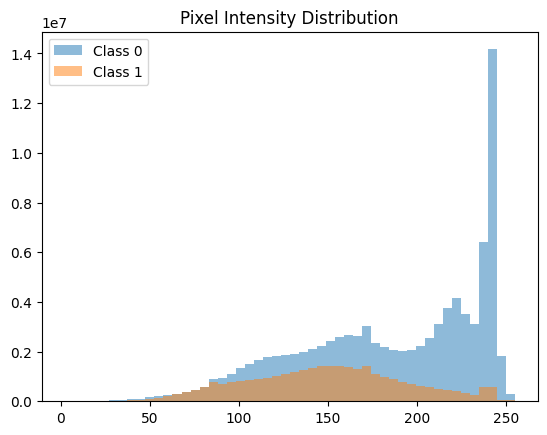

In [18]:
import matplotlib.pyplot as plt

plt.hist(train_0.flatten(), bins=50, alpha=0.5, label="Class 0")
plt.hist(train_1.flatten(), bins=50, alpha=0.5, label="Class 1")

plt.legend()
plt.title("Pixel Intensity Distribution")
plt.show()

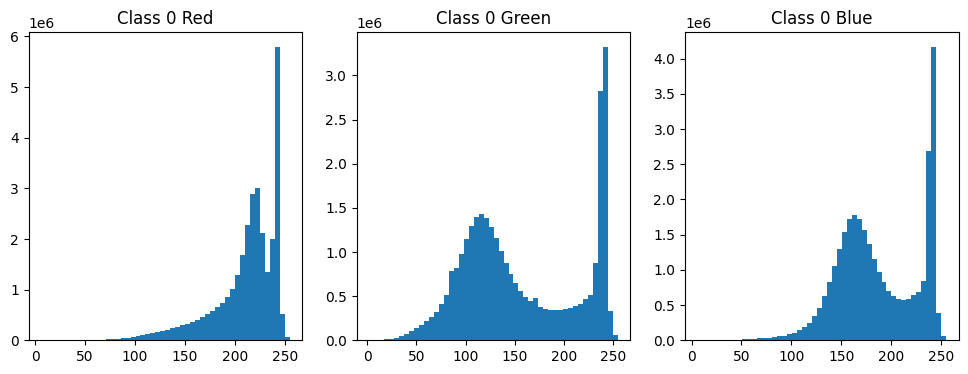

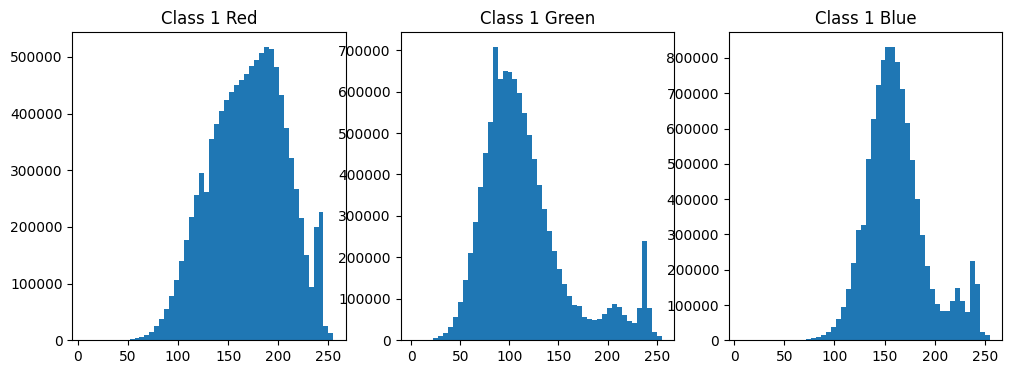

In [19]:
def plot_rgb_distribution(X, label):
    X = X.reshape(-1, 50, 50, 3)

    plt.figure(figsize=(12,4))
    
    for i, color in enumerate(["Red","Green","Blue"]):
        plt.subplot(1,3,i+1)
        plt.hist(X[:,:,:,i].flatten(), bins=50)
        plt.title(f"{label} {color}")
        
    plt.show()

plot_rgb_distribution(train_0, "Class 0")
plot_rgb_distribution(train_1, "Class 1")

In [20]:
print("Train samples:", X_train.shape)
print("Test samples:", X_test.shape)

Train samples: (16533, 7500)
Test samples: (3429, 7500)


Accuracy: 0.8346456692913385
              precision    recall  f1-score   support

         0.0     0.9493    0.8003    0.8685      2339
         1.0     0.6795    0.9083    0.7774      1090

    accuracy                         0.8346      3429
   macro avg     0.8144    0.8543    0.8229      3429
weighted avg     0.8635    0.8346    0.8395      3429



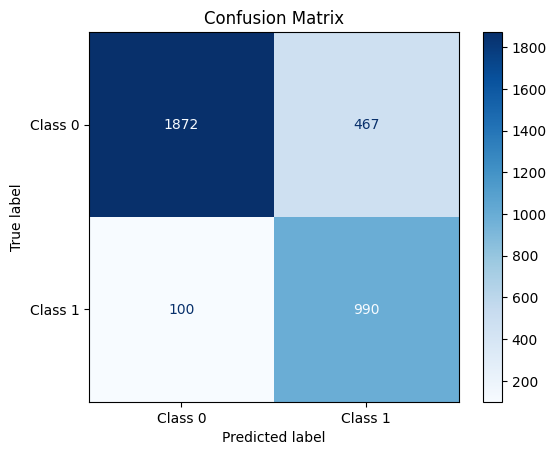

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=100, random_state=1234)),
    ("logreg", LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        solver='liblinear',
        random_state=1234
    ))
])

pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Class 0", "Class 1"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

ROC AUC: 0.9351589128891437


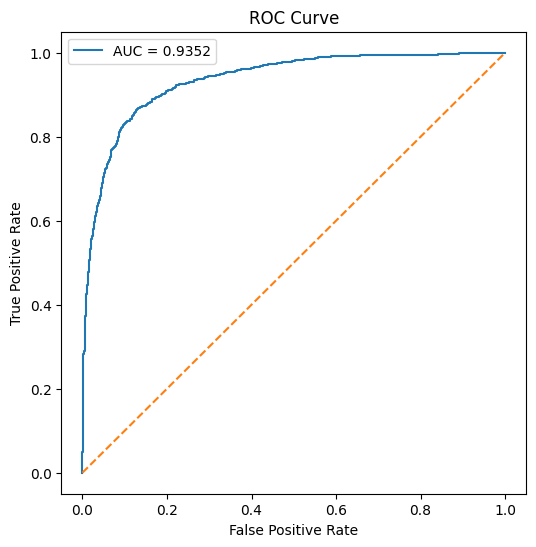

In [12]:
from sklearn.metrics import roc_curve, roc_auc_score

# if using clf directly
y_prob = pipe.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test, y_prob)
print("ROC AUC:", auc)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()